INTRODUZIONE ALLE GAN: GENERATORE VS DISCRIMINATORE

Mettere un artista continuamente davanti ad un critico d'arte

- Analogia del falsario e del poliziotto
- il generatore: trasformare il rumore statistico in dati. Braccio creativo.
- il discriminatore: il ruolo del critico d'arte. Sentinella che sorveglia i confini della realtà

Perchè la competizione è meglio della semplice imitazione?

Le GAN introducon l'apprendimento avversario
Non diciamo "fai come questo esempio" ma una sfida
Il falsario cerca di falsare una banconota, il poliziotto lo scopre, ma ogni volta che viene scoperto il falsario impara un nuovo trucco. Con il tempo il falsario diventa così bravo che il poliziotto defve affinare la sua vista per trovare i difetti microscopici. E' una rivalità che spinge entrambi verso ecellenza

Il cuore pulsante è un gioco a somma 0, in teorica dei giochi questo significa che il guadagno di uno è la perdita dell'altro.
Abbiamo due reti che coevolvono, Se il discriminatore diventa troppo pigro il generatore smette di migliorare, se il generatore è troopo debole il discriminatore non impare nulla.
Qui cerchiamo un equilibrio, non vogliamo che un rete vinca, ma che si sfidano per arrivare all'eccellenza.
Il miglioramento di una rete dipende direttamente dalla capactià dell'altra di metterla in difficoltà
A differenza degli autoencoder, qui non minimizziamo la distanza esplicita tra pixel. L'obbiettivo finale è un equilibrio in cui il generatore produce dati indistinguibili dalla realtà (oltre i propri limiti).
Seguiamo un ciclo di feeback che permette l'evoluzione. Questo processo è pertanto un ciclo continuo.
Attenzione alla sincronia
Se uno è un campione olimpico e l'altro un princpipiante, il principiante non impare perchè la sfida trooppo ardua. se il polizziotto è perfetto dal primo momento, il falsario va in confusione e l apprendimento si ferma.

Il generatore non vede mai una singola immagine reale, impare a disegnare un gatto senza averne mai visto uno, solo ascoltando i rifiuti del critico.
Punto in cui il generatore così perfetto che il discriminatore, per quanto espoerto deve arrendersi e tirare ad indovinare

Generatore G
LA nostra mentre creativa (GEneratore G) è il nostra artistca, il suo materiale di partenza è il caos, vettori casuali- Non ha accesso al dataset originale, la sua unica bussola è il punteggio che riceve dal suo avversario
Deve imparare a mappare numeri casuali in una struttura che noi umani riconosciamo come sensata, deve ricostruire immagine pixel dopo pixel, basnadosi solo sulle critiche che gli vengono passate.

Come fa un vettore di numeri a diventare poi un'immagine?

Tutto parte dallo spazio latente.
L'input è un vettore di rumore z campionato da una distribuzione nota, solimamente Gaussiana o Uniforme. Immagina z come un vettore di semi di possibilità.  
La rete G distorce piega questi vettori per arrivare che ogni coordinata definisce un concetto astratto. Campionare diversi z significa chiedere al modello 'fammi vedere un altra variante di cio che hai imparato'
Il Generatore agisce come una funzione di trasformazione non lineare complessa.
Ogni dimensione del vettore z può arrivare a rappresentare una feature astratta dell'output
Il campionamento permette di generare un'infinità di varianti diverse partendo dallo stesso modello.

Meccanismo di Generazione
Architetturalmente un Generatore per l'opposto di quello che fa un classificatore. Invece di restringere informazione la espande.
PArte da un piccolo vettore e strato dopo strato aumenta la risoluzione (architettura di espansione).
Deve imparare la coerenza, se decide di colorare un pixel di blu per farne un cielo, deve capire che anche i pixel circostanti devono essere coerenti a quel pixel.
G deve imparare quali combinazioni di pixel formano strutture coerenti come bordi, texture, e oggetti (apprendimento di feature).
Il successo di G si misura dalla sua capacità di produrre gradienti che spingano D a classificare il falso come vero (Inganno Strategico).

La Potenza dello Spazio Latente (latent space)
Navigare l'immagine
Lo spazio latente è il luovo dove risiedono i concetti compressi.
Muoversi nel vettore z, significa vedere l'immagine generata cambiare fluidamente da un'entità all'altra.
Poichè G è una fuznione continua, se cambiamo leggermente in vettore z l'immagine cambierà leggermente. Possiamo vedere letteralmente un volto che inizia a sorridere, semplicemente camminando tra questi numeri. Questa è la prova che la rete non ha solo memorizzato delle foto ma ha costruito un modello interno del mondo.

Conosciamo anche l'altra faccia della rete, la sentinella

Il Discriminatore 
Il discriminatore è un classificatore binario addestrato a distinguere i campioni reali del dataset da quelli sintetici prodotto da G
Se G è il falsario D è il suo insegnante più severo. Deve decidere cosa è vero e cosa è falso, quindi creato da G. senza la sua capacità di analisi il generatore rimarrebbe un bambino che scarabocchia nuo vuoto.
Il suo ruole è fondamentale, senza un critico severo o preciso, il generatore non saprebbe mai come migliorare le proprie creazioni.

Il discriminatore (D) riceve input sia da immagini reali che da immagini prodotte dal generatore G.
La sua uscita, è una probabilità singola che indica quanto l'input ricevuto sia ritenuto reale.
Più il suo valore è vicino a 1 più D è convinto che l'immagine sia reale.
Durante il suo addestramento i pesi del generatore sono congelati per fornitre un target stabilie.
D deve diventare un esperto del dataest reale, imparando ogni minima statistiche che contradistingue la realtà
Il discriminatore funge da insegnante dinamico fornendo la loss che il generatore deve minimizzare.

Il D impara a estrarre feature reali, diventa bravo a notare se i bordi sono reali, se i colori sono coerenti, tutto ciò che rende un immagine reale.
D deve essere in grado di individuare anche piccole incongruenze che tradiscono la natura sintetica del dato.
Attraverso il discriminatore l'informazione necessaria passa a G per capire quali pixel cambiare per sembrare più vero. Se nota un incongruenza la penaliza, questo errore non serve a punire il generatore ma a guidarlo attraverso il gradiente. 

Siamo davanti ad un compito in continua evoluzione. man mano che G impara a fare bordi perfetti, D deve imparare a fare le texture, quanto G guarda le textur D impara la simmetria, ecc ecc
E' questa rincorsa continua che produce il fotorealismo

Si usa più facilmante in pytorch

In [1]:
import torch
import torch.nn as nn

# --- GENERATORE ---
# Input: Vettore latente (100,) -> Output: Immagine piatta (784,)
generator = nn.Sequential(
    nn.Linear(100, 256),
    nn.ReLU(),
    nn.Linear(256, 512),
    nn.ReLU(),
    nn.Linear(512, 784),
    nn.Tanh()  # Fondamentale: porta i pixel nel range [-1, 1]
)

# --- DISCRIMINATORE ---
# Input: Immagine piatta (784,) -> Output: Probabilità (1,)
discriminator = nn.Sequential(
    nn.Linear(784, 512),
    nn.LeakyReLU(0.2), # Standard nelle GAN per evitare gradienti nulli
    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 1),
    nn.Sigmoid() # Output tra 0 e 1 (reale o falso)
)


# 1. Creiamo un vettore di rumore casuale (Latent Vector)
# Shape: (batch_size=1, latent_dim=100)
noise = torch.randn(1, 100)

# 2. Passaggio nel Generatore
fake_image = generator(noise)
print(f"Shape output Generatore: {fake_image.shape}") 
# Atteso: torch.Size([1, 784])

# 3. Passaggio nel Discriminatore
decision = discriminator(fake_image)
print(f"Shape output Discriminatore: {decision.shape}")
print(f"Valore di probabilità: {decision.item():.4f}")
# Atteso: torch.Size([1, 1])

Shape output Generatore: torch.Size([1, 784])
Shape output Discriminatore: torch.Size([1, 1])
Valore di probabilità: 0.4875



Discriminator:
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Inizio fase di addestramento dei modelli ...
Epoca [0/50] | Loss Discriminatore: 0.7902 | Loss Generator:  1.6526
Epoca [1/50] | Loss Discriminatore: 1.3182 | Loss Generator:  1.2530
Epoca [2/50] | Loss Discriminatore: 1.1103 | Loss Generator:  0.8712
Epoca [3/50] | Loss Discriminatore: 0.8830 | Loss Generator:  1.4990
Epoca [4/50] | Loss Discriminatore: 1.1245 | Loss Generator:  1.2005
Epoca [5/50] | Loss Discriminatore: 0.7986 | Loss Generator:  2.1662
Epoca [6/50] | Loss Discriminatore: 1.4790 | Loss Generator:  0.4286
Epoca [7/50] | Loss Discriminatore: 1.0908 | Loss Generator:  1.9105
Epoca [8/50] | Loss Discriminatore: 1.0519 | Loss Generator:  2

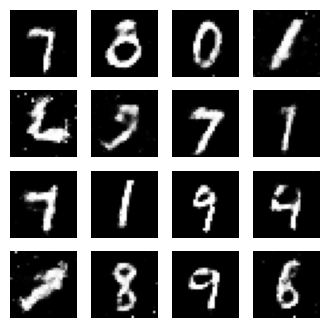

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==============================================================================
# CONFIGURAZIONE
# ==============================================================================

# --- Configurazione dei parametri e dell'ambiente ---
# modello e dati devono essere sullo stesso device
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Learning rate per gli ottimizzatori Adam, determina quanto cambiano i pesi ad ogni aggiornamento
lr=0.0002

# Parametro betal per l'ottimizzatore Adam, controlla il decadimento del primo momento
# adam non considera solo il gradiente corrente, mantiene una sorta di memoria dei gradienti precedenti
# beta1 controlla questa memoria (valore standard Adam è 0.9)
beta1 = 0.5

# Numero di campioni per ogni iterazione di addestramento
batch_size=128

# Dimensione dello spazio latente (vettore di rumore casuale in ingrasso al Generatore)
nz=100

# Numero totale di pixel per un'immagine (28x28)
img_size=784

# Numero di epoche totali per il processo di addestramento
num_epochs=50


# ==============================================================================
# DATASET
# ==============================================================================

# --- Preparazione del dataset ---
# Definizione delle trasformazioni: conversione in tensore e normalizzazione
# La normalizzazione porta i valori dei pixel nel range [-1,1]coerente con l'outpu Tanh del Generatore.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,),),
])

#utilizzo il dataset MNIST, il suo training_set ed applica la trasformazione transform
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# Caricamento del dataset MNIST (cifre scritte a mano)
dataloader=DataLoader(train_dataset, batch_size=batch_size,shuffle=True)



# --- Architettura dei Modelli: Note per chi proviene da Kers ... 

# In PyTorch, i modelli si creano come classi che ereditano da nn.Module (simile al Custom Models di Keras).
# A differenza di Keras (dove si usa model.add() o l'API functional), qui separiamo:
# 1. Definizione dei livelli (nel metodo __init__)
# 2. Passaggio dei dati (nel metodo forward)

# ==============================================================================
# GENERATOR
# ==============================================================================

class Generator(nn.Module):
    """
    GENERATOR: il suo scopo è apprendere la distribuzione dei  dati reali per produrre campioni sintetici.
    Input: vettore di rumore casuale di dimensione nz=100
    Output: Un'immagine 28x28x1 (MNIST)
    """
    def __init__(self):
        # Richiamo del costruttore della superclasse nn.Module (fondamentale per registrare i layer)
        super().__init__() #definisce i layer

        # nn.Sequential è l'equivalente della classe Sequential di Keras
        # Raggruppa i moduli da eseguire in ordine
        self.main = nn.Sequential(
            # nn.linear è l'equivalente di layers.Dense in Keras
            # NOTA: in Pytorch bisogna specificare SEMPRE sia la definizione di input che di output
            nn.Linear(nz,256), #riceve nz(100) caratteristiche e produce 256 caratteristiche
            nn.LeakyReLU(0.2), # Attivazione: restituisce x se x > 0, altrimenti 0.2*x, questo serve a mantenere sempre un minimo di informazione anche se x negativo (con solo relu se negativo porta a 0)

            nn.Linear(256,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),            

            # Strato di uscita: produrre 784 valori (28x28 pixel)
            nn.Linear(1024,img_size),
            # Tanh comprime l'output tra -1 e 1 (coerente con la normalizzazione dei dati fatta all'inizio)
            nn.Tanh()
        )

    def forward(self,x): #definisce come il dato attraversa i vari layers
        # A differenza del generatore, qui dobbiamo 'appiattire' l'immagine (Flatten).
        # x arriva già [batch_size,nx] quindi NON dobbiamo trasformalo in 784 elementi
        # Trasformiamo l'input [1,28,28] in un vettore [784]
        x=self.main(x)
        return x.view(-1,1,28,28)

# ==============================================================================
# DISCRIMINATOR
# ==============================================================================
# il discriminator fa l'opposto, riceve un'immagine e produce una probabilità
# qui l'immagine viene compressa progressivamente

class Discriminator(nn.Module):
    """
    DISCRIMINATOR
    Input: immagine 1 x 28 x 28
    Output: probabilità che l'immagine sia reale.
    """

    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(

            nn.Linear(img_size, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),

            # BCELoss richiede una probabilità tra 0 e 1
            nn.Sigmoid(),
            # es: 0.02 = quasi sicuramente fake 0.48 = molto incerto 0.97 = quasi sicuramente reale.
        )

    def forward(self, x):

        # Qui invece il Flatten serve.        
        # [batch, 1, 28, 28] -> [batch, 784]

        x = x.view(
            x.size(0),
            -1,
        )
        return self.main(x)


# ==============================================================================
# INIZIALIZZAZIONE MODELLI
# ==============================================================================

# --- Inizializzazione e Configurazione

# Creo i 2 modelli
netG= Generator().to(device)  #generator produce i pesi iniziali (pesi spazzatura all'inizio)
netD= Discriminator().to(device) #anche discriminator parte senza sapere cosa sia una cifra
# .to(device) invia tutti i parametri del modello sulla GPU (se disponibile) o CPU
# In Keras questo passaggio è solitamente gestito automaticamente del backend


print("\nDiscriminator:")
print(netD)

# Definizione della Loss Function (perdita)
# BCELoss = Binary Entropy Loss, usata perchè abbiamo un problema di classificazione si/no.

# ==============================================================================
# LOSS
# ==============================================================================

# Binary Cross Entropy:
#
# 1 = immagine reale, predizione corretta, loss piccola
# 0 = immagine falsa, predizione sbagliata, loss grande
criterion=nn.BCELoss()

# ==============================================================================
# OTTIMIZZATORI
# ==============================================================================

# I 2 Ottimizzatori
# A differenza di Keras (dove si passano gli otimizzatori e model.compile), in PyTorch
# 1. Ogni modello ha il proprio ottimizzatore (fonramentale per le GAN)
# 2. Dobbiamo passare esplicitamente i parametri da ottimizzare (es. netD.parameters())
optimizerD = optim.Adam(netD.parameters(),lr=lr,betas=(beta1, 0.999),)
optimizerG = optim.Adam(netG.parameters(),lr=lr,betas=(beta1, 0.999),)

# Valori di riferimento per le etichette (risposte che vogliamo insegnare a D)
real_label=1.
fake_label=0.

# --- Ciclo di addestramento ---

# In Keras, l'addestramento è spesso oscurato da model.fit()
# In OyTorch, scriviamo un ciclo for esplicito. Questo ci da il controllo totale
# su ogni operazione, fondamentale per arhitetture complesse come le GAN

# ==============================================================================
# TRAINING
# ==============================================================================

print("Inizio fase di addestramento dei modelli ...")

for epoch in range(num_epochs):
    # Iteriamo sui batch forniti dal Dataloader, real_images contiene le righe vere del Dataset.
    for i, (real_images,_) in enumerate(dataloader): #per ogni batch addestriamo D e addestriamo G

        real_images = real_images.to(device)
        b_size = real_images.size(0) #calcolliamo b_size invece di considerarlo sempre di 128 perchè l'ultimo batch potrebbe averne meno

        # ======================================================================
        # FASE 1
        # ADDESTRAMENTO DISCRIMINATOR
        # ======================================================================
        #         
        # --- FASE 1: Aggiornamento del Discriminatore (D) --
        # Obbiettivo: D deve imparare a distinguere  correttamente tra VERO o FALSO.

        # Svuotiamo i gradienti di D rimasti del batch precedente (obbligatoriamente in PyTorch)
        optimizerD.zero_grad()

        # ----------------------------------------------------------------------
        # 1A. IMMAGINI REALI
        # ----------------------------------------------------------------------        

        # 1.1 Passata con immagini reali
        # Creiamo un tensore di etichette '1' (real_label). vettore tutto di 1 (128 valori)
        label = torch.full((b_size,1),real_label, device=device)
        #Eseguiramo il discriminatore sulle immagini vere.
        output_real=netD(real_images)
        # Calcoliamo l'errore (quanto D si è sbagliato sulla immagini vere), 
        # confrontando predizioni D vs target = 1
        errD_real=criterion(output_real,label)
        # Calcoliamo i gradienti (derivate) solo per questa parte
        # calcola solo i gradienti (.backward) non modifica ancora i pesi (.step)
        errD_real.backward()

        # ----------------------------------------------------------------------
        # 1B. IMMAGINI FALSE
        # ----------------------------------------------------------------------        

        # 1.2 Passata con immagini generate (fonte)
        # Generiamo rumore casuale (punto di partenza per il generatore)
        noise = torch.randn(b_size,nz,device=device,)
        # il generatore crea immagini 'false' dal rumore
        fake_images = netG(noise)
        # Cambiamo l'etichetta obiettivo a '0' (fake_label)
        label.fill_(fake_label)

        # detach() impedisce ai gradienti di propagarsi
        # nel Generator durante il training di D.

        output_fake = netD(fake_images.detach())
        # Questo perchè in questa fase stiamo addestrando SOLO il Discriminatore
        # .detach() STACCA le immagini dal grafo del Generatore, impedendo che i
        # gradienti scorrano indietro verso G, risparmiando calcoli inutili (qui vogliamo allenare solo D).

        errD_fake=criterion(output_fake,label)
        # Calcoliamo i gradienti per la parte finta e li SOMMIAMO a quelli reali.
        errD_fake.backward()

        # Loss totale del discriminatore

        errD = (errD_real + errD_fake)

        # Dopo aver calcolato tutti i gradienti (reali e finti), aggiorniamo i pesi di D
        # Questo è il comando che effettivamente modifica i parametri della rete.
        optimizerD.step()
        #.backward()=calcolo dei gradienti  .step()=modifica i parametri

        # ======================================================================
        # FASE 2
        # ADDESTRAMENTO GENERATOR
        # ======================================================================

        # --- FASE 2: Aggiornamento del Generator (D) ---
        # Obbiettivo: G deve imparare a produrre immagini che D scambia per REALI.
        # In questa fase, G cerca di capire come modificare i sui pesi per far si che D
        # classifichi i suoi prodotti sintetici come 'reali'

        # Svuotiamo i gradienti accumulati per il Generatore (netG)
        optimizerG.zero_grad()

        # IL PARADOSSO DELLE ETICHETTE.
        # Anche se sappiamo che fake_images sono finte, forniamo a D l'etihetta '1' (real_labesl)
        # Perchè? perchè vogliamo calcolare la 'distanza' tra ciò che D pensa (probabilmente vicino a 0)
        # e ciò che G vorrebbe fargli pensare (ossia 1). L'errore risultante guiderà G
        # Ora vogliamo che D consideri le immagini generate come reali.
        label.fill_(real_label) #trasformo le etichette in 1=immagni reali (per far finta che siano vere)

        # ATTENZIONE:
        # dobbiamo ripassare fake_images nel Discriminator SENZA detach().

        output_for_G = netD(fake_images)

        # Calcoliamo la loss: errG sarà alta se D ha scoperto il trucco, basse se G ha vinto
        errG=criterion(output_for_G,label)

        # LA BACKPROPAGAZIONE ATTRAVERSO IL NEMICO
        # Chiamando .backword(), il gradiente viaggia all'indietro partendo dall'errore di D
        # passa attraverso i pesi di D (sena modificarli, poichè useremo solo optimizerG)
        # e arriva dritto ai pesi di G. I come se G usasse il cervello di D per imparare.
        # Il gradiente attraversa:
        # loss -> Discriminator -> Generator 
        # ma optimizerG aggiornerà solamente i parametri di G.        
        errG.backward()

        # Applichiamo i cambiamenti ai pesi di G per migliorare la qualità delle immagini
        optimizerG.step()

    # ======================================================================
    # LOG EPOCA
    # ======================================================================

    print(f"Epoca [{epoch}/{num_epochs}] | Loss Discriminatore: {errD_real+errD_fake:.4f} | Loss Generator: {errG: .4f}")

# ==============================================================================
# GENERAZIONE FINALE
# ==============================================================================

# -- Generazione e Visualizzazione Finale dei Risultati ---
with torch.no_grad():
    # Campionamento di rumore per generare 16 immagini di test
    noise=torch.randn(16,nz,device=device)
    # Disabilita il calcolo del gradiente per la visualizzazione
    fake_imgs = netG(noise).cpu()

# ==============================================================================
# VISUALIZZAZIONE
# ==============================================================================

# Creazione di una griglia 4x4 per mostrare i numeri generati
plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4,4,i+1)
    # Rimuove le dimensioni extra e mostra l'immagine in scala di grigi
    plt.imshow(fake_imgs[i].squeeze(),cmap='gray')
    plt.axis('off')
plt.show()

